# 02 Exploratory and Benchmark Analysis

This notebook produces the site-level PTAL distributions, annual trends, London-wide grid benchmark, borough-relative benchmark, and threshold-sensitivity outputs used in the dissertation.


## 1. Setup


In [4]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path(".")
BASE = PROJECT_ROOT

OUTPUT_DIR = PROJECT_ROOT / "outputs"

print("Current working directory:", Path.cwd())
print("Base directory:", BASE.resolve())
print("Output directory:", OUTPUT_DIR.resolve())

FIG_DIR = OUTPUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = OUTPUT_DIR / "pld_completed_housing_with_ptal_main_2015_2025.gpkg"

analysis_gdf = gpd.read_file(DATA_PATH)

analysis_gdf.head()

Current working directory: C:\Users\YOLO\GitHub\CASA\dissertation\project\notebook\code
Base directory: C:\Users\YOLO\GitHub\CASA\dissertation\project\notebook\code
Output directory: C:\Users\YOLO\GitHub\CASA\dissertation\project\notebook\code\outputs


,LPA Number,Borough,Valid date,Status,Application type,Description,Site name,Site number,Street name,Locality,...,lsoa11cd,lsoa21cd,_merge,PTAL_2023,ptal_band,ptal_medium_high,ptal_high,index_right,borough_spatial,geometry
0,221164FUL,Ealing,17/03/2022,Completed,All Other,Change of use of single family dwellinghouse (...,65 Twyford Abbey Road,None,Twyford Abbey Road,London,...,E01001276,E01001276,both,4,Medium,True,False,4.0,Ealing,POINT (518888 182894)
1,10/03970/FULL,Westminster,None,Completed,All Other,Renewal of extant planning permission dated 02...,"Windsor House, 55-56","Windsor House, 55-56",St James's Street,None,...,E01004736,E01004736,both,6b,High,True,True,25.0,Westminster,POINT (529167 180313)
2,11/01869/RG4,Lambeth,None,Completed,All Other,Redevelopment of the site involving demolition...,Claremont East Housing Estate,Claremont East Housing Estate,Streatham Hill,None,...,E01003174,E01003174,both,4,Medium,True,False,15.0,Lambeth,POINT (531483 172994)
3,12/AP/3161,Southwark,None,Completed,All Other,Conversion of top floor maisonette into two se...,15,15,Risborough Street,None,...,E01003927,E01033867,both,6b,High,True,True,22.0,Southwark,POINT (531974 179986)
4,14/10040/FUL,Kingston upon Thames,None,Completed,All Other,Conversion of existing house into 1 x 3 bedroo...,28,28,WOODGATE AVENUE,None,...,E01002941,E01002941,both,1b,Low,False,False,0.0,Kingston upon Thames,POINT (517696 164444)


In [5]:
from matplotlib.colors import LinearSegmentedColormap

# ---------------------------------------------------------
# Common map style
# ---------------------------------------------------------

plt.rcParams.update({
    "figure.facecolor": "#FFFFFF",
    "savefig.facecolor": "#FFFFFF",
    "axes.facecolor": "#FFFFFF",

    "font.family": "sans-serif",
    "font.sans-serif": [
        "DejaVu Sans",
        "Arial",
        "Liberation Sans",
    ],
    "font.size": 11,

    "axes.titlesize": 17,
    "axes.titleweight": "normal",
    "axes.titlecolor": "#1A1A1A",

    "legend.fontsize": 9,
    "legend.title_fontsize": 10,

    "text.color": "#1A1A1A",
})


# ---------------------------------------------------------
# Read MSOA 2011 boundaries
# ---------------------------------------------------------

MSOA_PATH = BASE / "MSOA_2011_London_gen_MHW.shp"

msoa = gpd.read_file(
    MSOA_PATH
).to_crs("EPSG:27700")


# Identify the MSOA code column
possible_msoa_code_cols = [
    "MSOA11CD",
    "msoa11cd",
    "MSOA11_CODE",
    "msoa11_code",
]

msoa_code_col = next(
    (
        column
        for column in possible_msoa_code_cols
        if column in msoa.columns
    ),
    None,
)

if msoa_code_col is None:
    raise ValueError(
        "Could not identify the MSOA code column. "
        f"Available columns: {msoa.columns.tolist()}"
    )


msoa = (
    msoa
    .rename(
        columns={
            msoa_code_col: "msoa11cd"
        }
    )
    [["msoa11cd", "geometry"]]
    .drop_duplicates(
        subset="msoa11cd"
    )
    .copy()
)

msoa = msoa[
    msoa.geometry.notna()
    & ~msoa.geometry.is_empty
].copy()


# One dissolved polygon, used to draw only the London outer outline
london_outline = msoa.dissolve()


# ---------------------------------------------------------
# Spatially assign housing points to MSOAs
# ---------------------------------------------------------

analysis_points = (
    analysis_gdf
    .to_crs("EPSG:27700")
    .drop(
        columns=[
            "index_left",
            "index_right",
            "msoa11cd",
        ],
        errors="ignore",
    )
    .copy()
)

points_msoa = gpd.sjoin(
    analysis_points,
    msoa[
        [
            "msoa11cd",
            "geometry",
        ]
    ],
    how="inner",
    predicate="within",
)


print(
    "Housing records matched to an MSOA:",
    len(points_msoa),
)

print(
    "Completed units matched to an MSOA:",
    points_msoa["completed_units"].sum(),
)

print(
    "MSOAs containing at least one housing record:",
    points_msoa["msoa11cd"].nunique(),
)


# ---------------------------------------------------------
# Helper functions
# ---------------------------------------------------------

def remove_polygon_seams(ax):
    """
    Remove anti-aliasing seams between adjoining polygons.
    """
    for collection in ax.collections:
        if hasattr(
            collection,
            "set_antialiaseds",
        ):
            collection.set_antialiaseds(False)

        if hasattr(
            collection,
            "set_linewidths",
        ):
            collection.set_linewidths(0)

        if hasattr(
            collection,
            "set_edgecolors",
        ):
            collection.set_edgecolors("none")


def add_scale_bar(
    ax,
    length_km=10,
    location=(0.72, 0.04),
    linewidth=4,
):
    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()

    bar_length_metres = length_km * 1000
    segment_length = bar_length_metres / 2

    start_x = (
        x_min
        + (x_max - x_min) * location[0]
    )

    start_y = (
        y_min
        + (y_max - y_min) * location[1]
    )

    # Dark first segment
    ax.plot(
        [
            start_x,
            start_x + segment_length,
        ],
        [
            start_y,
            start_y,
        ],
        color="#333333",
        linewidth=linewidth,
        solid_capstyle="butt",
        zorder=20,
    )

    # White second segment
    ax.plot(
        [
            start_x + segment_length,
            start_x + 2 * segment_length,
        ],
        [
            start_y,
            start_y,
        ],
        color="#FFFFFF",
        linewidth=linewidth,
        solid_capstyle="butt",
        zorder=20,
    )

    # Outline for the white segment
    ax.plot(
        [
            start_x + segment_length,
            start_x + 2 * segment_length,
        ],
        [
            start_y,
            start_y,
        ],
        color="#333333",
        linewidth=1,
        zorder=21,
    )

    label_y = (
        start_y
        - (y_max - y_min) * 0.015
    )

    ax.text(
        start_x,
        label_y,
        "0",
        ha="center",
        va="top",
        fontsize=8,
        color="#333333",
    )

    ax.text(
        start_x + segment_length,
        label_y,
        f"{length_km // 2}",
        ha="center",
        va="top",
        fontsize=8,
        color="#333333",
    )

    ax.text(
        start_x + 2 * segment_length,
        label_y,
        f"{length_km} km",
        ha="center",
        va="top",
        fontsize=8,
        color="#333333",
    )


def add_north_arrow(
    ax,
    location=(0.94, 0.92),
    size=0.05,
):
    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()

    centre_x = (
        x_min
        + (x_max - x_min) * location[0]
    )

    centre_y = (
        y_min
        + (y_max - y_min) * location[1]
    )

    arrow_length = (
        y_max - y_min
    ) * size

    ax.annotate(
        "N",
        xy=(
            centre_x,
            centre_y + arrow_length,
        ),
        xytext=(
            centre_x,
            centre_y,
        ),
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="#333333",
        arrowprops={
            "arrowstyle": "-|>",
            "color": "#333333",
            "linewidth": 1.5,
        },
        zorder=20,
    )

Housing records matched to an MSOA: 25829
Completed units matched to an MSOA: 225104.0
MSOAs containing at least one housing record: 982


In [6]:
print(analysis_gdf.shape)
print(analysis_gdf.crs)
print(analysis_gdf["completion_financial_year"].value_counts().sort_index())
print(analysis_gdf["ptal_band"].value_counts(dropna=False))

(25852, 48)
EPSG:27700
completion_financial_year
2015/16    2746
2016/17    3940
2017/18    3288
2018/19    3249
2019/20    3179
2020/21    2368
2021/22    2494
2022/23     813
2023/24    2121
2024/25    1654
Name: count, dtype: int64
ptal_band
Medium    9426
Low       9142
High      7261
None        23
Name: count, dtype: int64


## 2. Read summary tables

### 2.1 Raw PLD coverage

In [7]:
annual_summary = pd.read_csv(OUTPUT_DIR / "annual_pld_completion_summary.csv")
geocoding_summary = pd.read_csv(OUTPUT_DIR / "summary_geocoding_coverage.csv")
ptal_join_summary = pd.read_csv(OUTPUT_DIR / "summary_ptal_join_coverage.csv")
ptal_summary = pd.read_csv(OUTPUT_DIR / "summary_completed_units_by_ptal_band.csv")
annual_accessibility = pd.read_csv(OUTPUT_DIR / "summary_annual_accessibility_share.csv")
borough_summary = pd.read_csv(OUTPUT_DIR / "summary_borough_accessibility.csv")

In [8]:
geocoding_summary

,stage,records,completed_units,record_share_of_core,unit_share_of_core
0,Core completed PLD records,27863,296746.0,100.00%,100.00%
1,Records with extractable postcode,25922,226657.0,93.03%,76.38%
2,Records without extractable postcode,1941,70089.0,6.97%,23.62%
3,Matched to ONSPD coordinates,25852,225451.0,92.78%,75.97%
4,Valid postcode but not matched to ONSPD,70,1206.0,0.25%,0.41%


### 2.2 Main analysis sample, 2015/16–2024/25

In [9]:
main_years = [
    "2015/16", "2016/17", "2017/18", "2018/19", "2019/20",
    "2020/21", "2021/22", "2022/23", "2023/24", "2024/25"
]

In [10]:
main_coverage_summary = pd.read_csv(
    OUTPUT_DIR / "summary_main_analysis_coverage.csv"
)

main_coverage_summary

,category,records,completed_units,record_share_of_core,unit_share_of_core
0,Core completed PLD records,27863,296746.0,100.00%,100.00%
1,Excluded: no extractable postcode,1941,70089.0,6.97%,23.62%
2,Excluded: postcode not matched to ONSPD,70,1206.0,0.25%,0.41%
3,Final geocoded sample,25852,225451.0,92.78%,75.97%


## 3. Annual completion coverage

In [11]:
main_years = [
    "2015/16", "2016/17", "2017/18", "2018/19", "2019/20",
    "2020/21", "2021/22", "2022/23", "2023/24", "2024/25"
]

annual_core = annual_summary[
    annual_summary["completion_financial_year"].isin(main_years)
].copy()

annual_geocoded = (
    analysis_gdf
    .groupby("completion_financial_year")
    .agg(
        geocoded_units=("completed_units", "sum"),
        geocoded_records=("LPA Number", "count")
    )
    .reset_index()
)

annual_compare = annual_core.merge(
    annual_geocoded,
    on="completion_financial_year",
    how="left"
)

annual_compare["geocoded_unit_share"] = (
    annual_compare["geocoded_units"] / annual_compare["completed_units"]
)

annual_compare

,completion_financial_year,records,completed_units,geocoded_units,geocoded_records,geocoded_unit_share
0,2015/16,2955,25475.0,19451.0,2746,0.763533
1,2016/17,4191,41183.0,31612.0,3940,0.767598
2,2017/18,3445,33885.0,26926.0,3288,0.794629
3,2018/19,3423,34050.0,26280.0,3249,0.771806
4,2019/20,3364,35953.0,27636.0,3179,0.768670
5,2020/21,2630,28463.0,20728.0,2368,0.728244
6,2021/22,2781,30606.0,21957.0,2494,0.717408
7,2022/23,887,13663.0,11074.0,813,0.810510
8,2023/24,2363,29116.0,21476.0,2121,0.737601
9,2024/25,1824,24352.0,18311.0,1654,0.751930


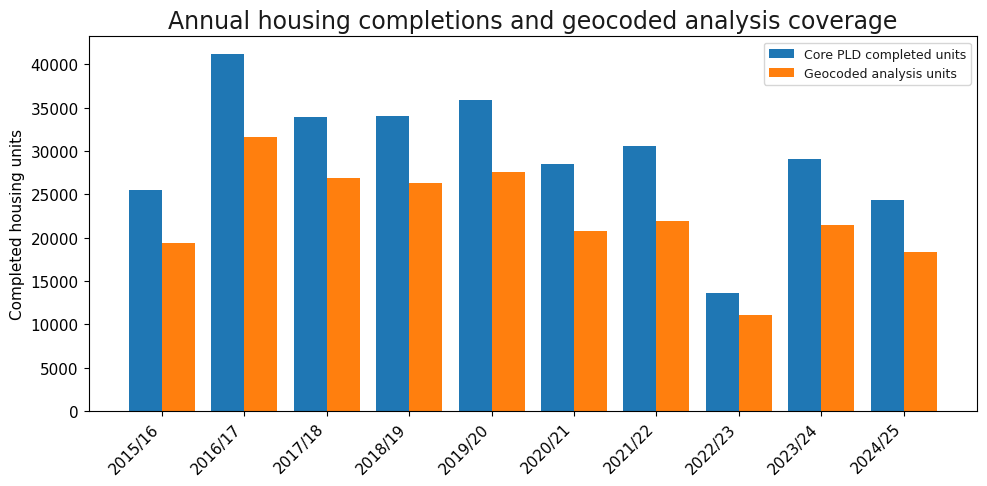

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(annual_compare))
width = 0.4

ax.bar(
    x - width/2,
    annual_compare["completed_units"],
    width,
    label="Core PLD completed units"
)

ax.bar(
    x + width/2,
    annual_compare["geocoded_units"],
    width,
    label="Geocoded analysis units"
)

ax.set_xticks(x)
ax.set_xticklabels(annual_compare["completion_financial_year"], rotation=45, ha="right")
ax.set_ylabel("Completed housing units")
ax.set_title("Annual housing completions and geocoded analysis coverage")
ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "fig01_annual_units_geocoded_coverage.png", dpi=300)
plt.show()

## 4. Site-level PTAL distribution

In [13]:
ptal_order = ["Low", "Medium", "High"]

ptal_plot = ptal_summary[
    ptal_summary["ptal_band"].isin(ptal_order)
].copy()

ptal_plot["ptal_band"] = pd.Categorical(
    ptal_plot["ptal_band"],
    categories=ptal_order,
    ordered=True
)

ptal_plot = ptal_plot.sort_values("ptal_band")
ptal_plot

,ptal_band,records,completed_units,record_share,unit_share
1,Low,9142,63459.0,0.353628,0.281476
2,Medium,9426,72077.0,0.364614,0.319701
0,High,7261,89568.0,0.280868,0.397284


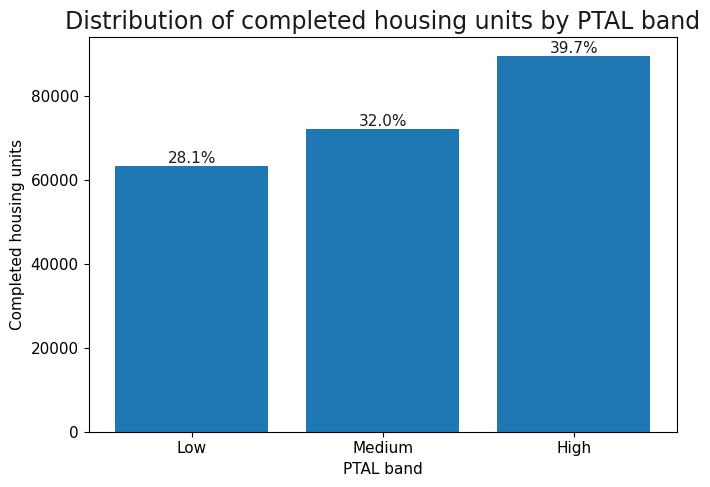

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(
    ptal_plot["ptal_band"],
    ptal_plot["completed_units"]
)

ax.set_xlabel("PTAL band")
ax.set_ylabel("Completed housing units")
ax.set_title("Distribution of completed housing units by PTAL band")

for i, row in ptal_plot.iterrows():
    ax.text(
        row["ptal_band"],
        row["completed_units"],
        f"{row['unit_share']:.1%}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig(FIG_DIR / "fig02_completed_units_by_ptal_band.png", dpi=300)
plt.show()

## 5. Annual accessible share

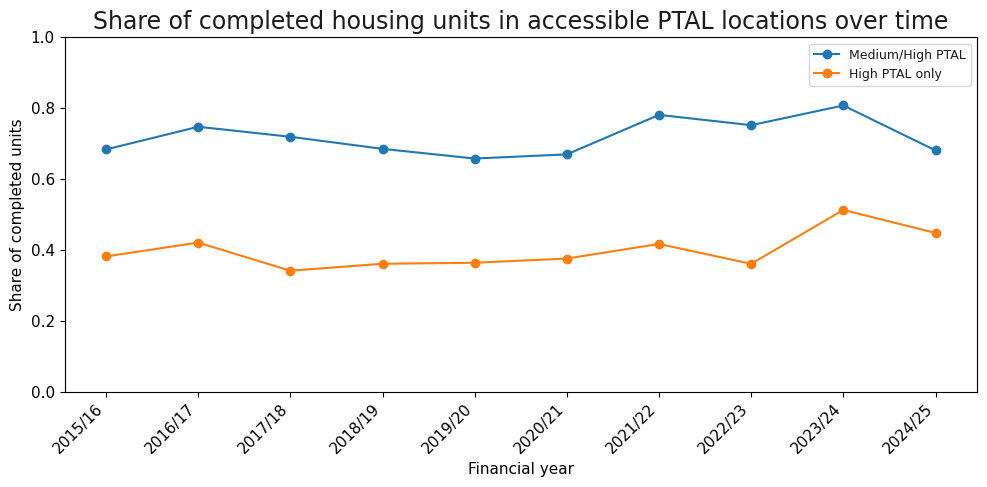

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(annual_accessibility))

ax.plot(
    x,
    annual_accessibility["share_units_medium_high"],
    marker="o",
    label="Medium/High PTAL"
)

ax.plot(
    x,
    annual_accessibility["share_units_high"],
    marker="o",
    label="High PTAL only"
)

ax.set_xticks(x)
ax.set_xticklabels(
    annual_accessibility["completion_financial_year"],
    rotation=45,
    ha="right"
)

ax.set_ylim(0, 1)
ax.set_ylabel("Share of completed units")
ax.set_xlabel("Financial year")
ax.set_title("Share of completed housing units in accessible PTAL locations over time")
ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "fig03_annual_accessibility_share.png", dpi=300)
plt.show()

## 6. Borough comparisons

### 6.1 Absolute accessibility shares

In [16]:
borough_plot = borough_summary[
    borough_summary["borough_spatial"].notna()
].copy()

borough_plot = borough_plot.sort_values("share_units_medium_high", ascending=True)

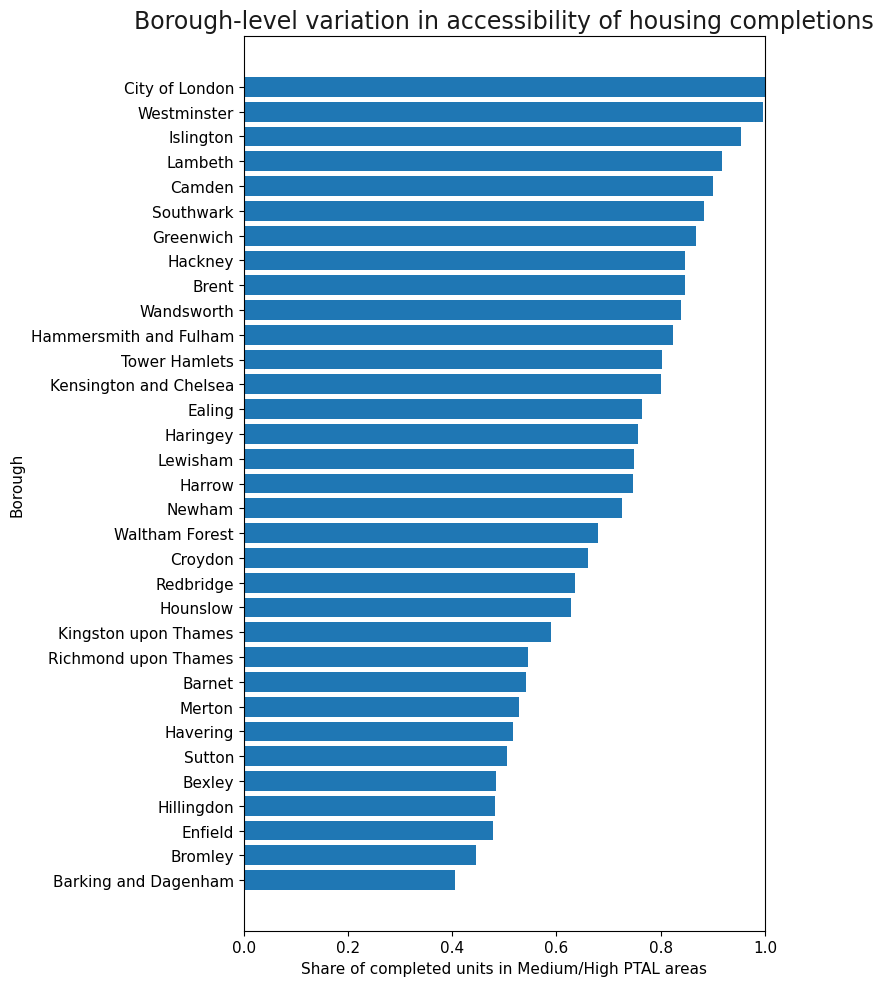

In [17]:
fig, ax = plt.subplots(figsize=(8, 10))

ax.barh(
    borough_plot["borough_spatial"],
    borough_plot["share_units_medium_high"]
)

ax.set_xlabel("Share of completed units in Medium/High PTAL areas")
ax.set_ylabel("Borough")
ax.set_title("Borough-level variation in accessibility of housing completions")
ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig(
    FIG_DIR / "appendix_borough_absolute_medium_high_share.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="#FFFFFF",
)
plt.show()

### 6.2 Delivery volume and accessibility

In [18]:
borough_scatter = borough_summary[
    borough_summary["borough_spatial"].notna()
].copy()

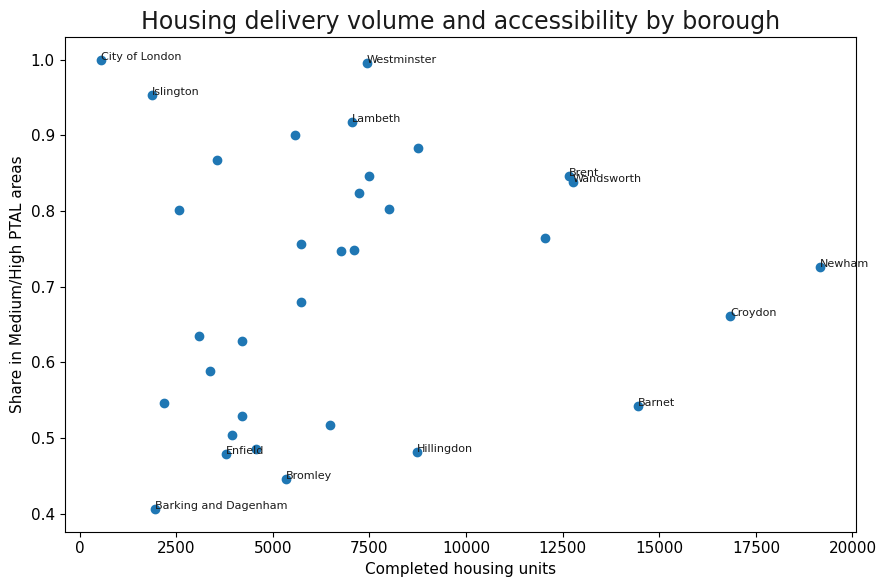

In [19]:
high_delivery_threshold = borough_scatter["completed_units"].quantile(0.85)
high_access_threshold = borough_scatter["share_units_medium_high"].quantile(0.90)
low_access_threshold = borough_scatter["share_units_medium_high"].quantile(0.10)

borough_scatter["label_point"] = (
    (borough_scatter["completed_units"] >= high_delivery_threshold) |
    (borough_scatter["share_units_medium_high"] >= high_access_threshold) |
    (borough_scatter["share_units_medium_high"] <= low_access_threshold)
)

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    borough_scatter["completed_units"],
    borough_scatter["share_units_medium_high"]
)

ax.set_xlabel("Completed housing units")
ax.set_ylabel("Share in Medium/High PTAL areas")
ax.set_title("Housing delivery volume and accessibility by borough")

for _, row in borough_scatter[borough_scatter["label_point"]].iterrows():
    ax.text(
        row["completed_units"],
        row["share_units_medium_high"],
        row["borough_spatial"],
        fontsize=8
    )

plt.tight_layout()
plt.savefig(
    FIG_DIR / "appendix_borough_units_vs_absolute_accessibility.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="#FFFFFF",
)
plt.show()

## 7. London-wide PTAL grid benchmark

In [20]:
PTAL_PATH = BASE / "PTAL_2023_Grid_100mx100m_Data.geojson"

ptal_grid = gpd.read_file(PTAL_PATH)

print(ptal_grid.shape)
print(ptal_grid.columns)
ptal_grid.head()

(159451, 12)
Index(['FID', 'GridID', 'BUS', 'LUL', 'RAIL', 'TRAM', 'AI', 'PTAL_2023',
       'Shape_Leng', 'Shape__Area', 'Shape__Length', 'geometry'],
      dtype='object')


,FID,GridID,BUS,LUL,RAIL,TRAM,AI,PTAL_2023,Shape_Leng,Shape__Area,Shape__Length,geometry
0,1,1501,5.100872,0.0,0.0,0.0,5.100872,2,400.0,10000.0,400.0,"POLYGON ((-0.12193 51.31056, -0.1219 51.31146,..."
1,2,1502,3.610841,0.0,0.0,0.0,3.610841,1b,400.0,10000.0,400.0,"POLYGON ((-0.1205 51.31054, -0.12046 51.31144,..."
2,3,1503,3.198376,0.0,0.0,0.0,3.198376,1b,400.0,10000.0,400.0,"POLYGON ((-0.11906 51.31052, -0.11903 51.31142..."
3,4,1504,2.292348,0.0,0.0,0.0,2.292348,1a,400.0,10000.0,400.0,"POLYGON ((-0.11763 51.31049, -0.11759 51.31139..."
4,5,1505,4.662443,0.0,0.0,0.0,4.662443,1b,400.0,10000.0,400.0,"POLYGON ((-0.1162 51.31047, -0.11616 51.31137,..."


In [21]:
def classify_ptal(value):
    if pd.isna(value):
        return np.nan
    
    value = str(value).strip().lower()
    
    if value in ["0", "1a", "1b", "2"]:
        return "Low"
    elif value in ["3", "4"]:
        return "Medium"
    elif value in ["5", "6a", "6b"]:
        return "High"
    else:
        return np.nan

ptal_grid["ptal_band"] = ptal_grid["PTAL_2023"].apply(classify_ptal)

In [22]:
ptal_grid_baseline = (
    ptal_grid
    .groupby("ptal_band", dropna=False)
    .agg(
        grid_cells=("GridID", "count")
    )
    .reset_index()
)

ptal_grid_baseline["grid_cell_share"] = (
    ptal_grid_baseline["grid_cells"] /
    ptal_grid_baseline["grid_cells"].sum()
)

ptal_grid_baseline

,ptal_band,grid_cells,grid_cell_share
0,High,14781,0.092699
1,Low,114930,0.720786
2,Medium,29740,0.186515


In [23]:
ptal_comparison = ptal_plot[
    ["ptal_band", "completed_units", "unit_share"]
].merge(
    ptal_grid_baseline[["ptal_band", "grid_cell_share"]],
    on="ptal_band",
    how="left"
)

ptal_comparison

,ptal_band,completed_units,unit_share,grid_cell_share
0,Low,63459.0,0.281476,0.720786
1,Medium,72077.0,0.319701,0.186515
2,High,89568.0,0.397284,0.092699


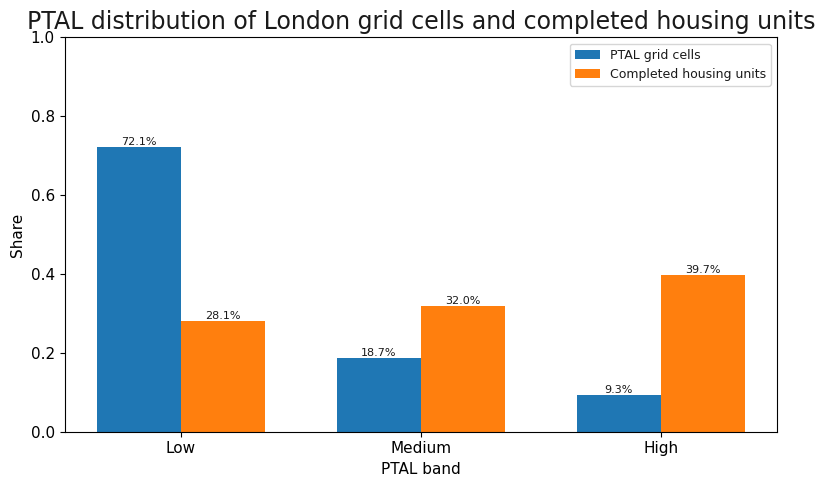

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(ptal_comparison))
width = 0.35

bars1 = ax.bar(
    x - width/2,
    ptal_comparison["grid_cell_share"],
    width,
    label="PTAL grid cells"
)

bars2 = ax.bar(
    x + width/2,
    ptal_comparison["unit_share"],
    width,
    label="Completed housing units"
)

ax.set_xticks(x)
ax.set_xticklabels(ptal_comparison["ptal_band"])
ax.set_ylabel("Share")
ax.set_xlabel("PTAL band")
ax.set_ylim(0, 1)
ax.set_title("PTAL distribution of London grid cells and completed housing units")
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{height:.1%}",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.tight_layout()
plt.savefig(FIG_DIR / "fig06_ptal_grid_baseline_comparison_labelled.png", dpi=300)
plt.show()

In [25]:
ptal_comparison.to_csv(
    OUTPUT_DIR / "summary_ptal_grid_baseline_comparison.csv",
    index=False
)

## 8. Borough-relative PTAL benchmark

In [26]:
# ---------------------------------------------------------
# Borough-relative accessibility baseline
# ---------------------------------------------------------

BOROUGH_PATH = BASE / "London_Boroughs.gpkg"

boroughs = gpd.read_file(
    BOROUGH_PATH
).to_crs("EPSG:27700")


# Identify borough name column
possible_borough_name_cols = [
    "name",
    "NAME",
    "borough",
    "Borough",
    "borough_name",
    "LAD22NM",
    "LAD23NM",
]

borough_name_col = next(
    (
        column
        for column in possible_borough_name_cols
        if column in boroughs.columns
    ),
    None,
)

if borough_name_col is None:
    raise ValueError(
        "Could not identify borough name column. "
        f"Available columns: {boroughs.columns.tolist()}"
    )


boroughs_for_join = (
    boroughs
    .rename(
        columns={
            borough_name_col: "borough_spatial"
        }
    )
    [["borough_spatial", "geometry"]]
    .copy()
)


# ---------------------------------------------------------
# Assign each PTAL grid cell to a borough using its centroid
# ---------------------------------------------------------

ptal_grid_bng = (
    ptal_grid
    .to_crs("EPSG:27700")
    .copy()
)

ptal_centres = (
    ptal_grid_bng[
        [
            "GridID",
            "ptal_band",
            "geometry",
        ]
    ]
    .dropna(
        subset=["ptal_band"]
    )
    .copy()
)

ptal_centres["geometry"] = (
    ptal_centres.geometry.centroid
)


borough_grid_join = gpd.sjoin(
    ptal_centres,
    boroughs_for_join,
    how="left",
    predicate="within",
)


print(
    "PTAL grid cells without borough:",
    borough_grid_join["borough_spatial"].isna().sum(),
)


# Medium/High PTAL indicator for each grid cell
borough_grid_join["grid_medium_high"] = (
    borough_grid_join["ptal_band"]
    .isin(
        [
            "Medium",
            "High",
        ]
    )
    .astype(int)
)


borough_grid_summary = (
    borough_grid_join
    .dropna(
        subset=["borough_spatial"]
    )
    .groupby("borough_spatial")
    .agg(
        ptal_grid_cells=(
            "GridID",
            "count",
        ),
        medium_high_grid_cells=(
            "grid_medium_high",
            "sum",
        ),
    )
    .reset_index()
)


borough_grid_summary[
    "share_grid_medium_high"
] = (
    borough_grid_summary[
        "medium_high_grid_cells"
    ]
    / borough_grid_summary[
        "ptal_grid_cells"
    ]
)


# ---------------------------------------------------------
# Merge local grid baseline with housing completion results
# ---------------------------------------------------------

borough_relative = (
    borough_summary[
        borough_summary[
            "borough_spatial"
        ].notna()
    ]
    .merge(
        borough_grid_summary,
        on="borough_spatial",
        how="left",
    )
    .copy()
)


borough_relative[
    "difference_percentage_points"
] = (
    borough_relative[
        "share_units_medium_high"
    ]
    - borough_relative[
        "share_grid_medium_high"
    ]
) * 100


borough_relative[
    "share_units_medium_high_pct"
] = (
    borough_relative[
        "share_units_medium_high"
    ]
    * 100
)


borough_relative[
    "share_grid_medium_high_pct"
] = (
    borough_relative[
        "share_grid_medium_high"
    ]
    * 100
)


# Bubble size represents completed housing volume
borough_relative["marker_size"] = (
    np.sqrt(
        borough_relative["completed_units"]
    )
    * 1.5
)


borough_relative.to_csv(
    OUTPUT_DIR
    / "summary_borough_relative_accessibility.csv",
    index=False,
)


display(
    borough_relative[
        [
            "borough_spatial",
            "completed_units",
            "share_units_medium_high",
            "share_grid_medium_high",
            "difference_percentage_points",
        ]
    ]
    .sort_values(
        "difference_percentage_points",
        ascending=False,
    )
)

PTAL grid cells without borough: 0


,borough_spatial,completed_units,share_units_medium_high,share_grid_medium_high,difference_percentage_points
6,Greenwich,3544.0,0.867664,0.339544,52.811955
16,Harrow,6755.0,0.747742,0.220087,52.765525
19,Croydon,16832.0,0.661359,0.179087,48.227208
26,Havering,6490.0,0.516641,0.065257,45.138371
22,Kingston upon Thames,3370.0,0.589021,0.142934,44.608701
20,Redbridge,3076.0,0.634915,0.210097,42.481804
21,Hounslow,4212.0,0.628680,0.212706,41.597425
23,Richmond upon Thames,2183.0,0.546038,0.145172,40.086527
18,Waltham Forest,5719.0,0.679664,0.285530,39.413423
13,Ealing,12040.0,0.764535,0.381638,38.289672


Saving figure to: C:\Users\YOLO\GitHub\CASA\dissertation\project\notebook\code\outputs\figures\fig_borough_relative_ptal_baseline_v2.png


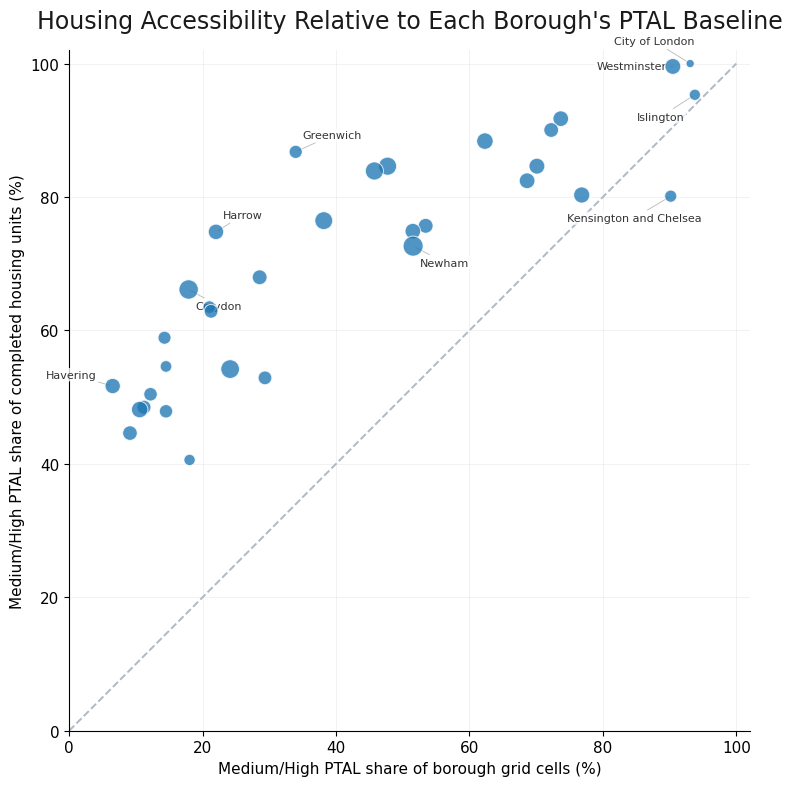

In [27]:
# ---------------------------------------------------------
# Plot borough-relative accessibility
# ---------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8.5, 8),
    facecolor="#FFFFFF",
)


ax.scatter(
    borough_relative[
        "share_grid_medium_high_pct"
    ],
    borough_relative[
        "share_units_medium_high_pct"
    ],
    s=borough_relative["marker_size"],
    color="#1f77b4",
    alpha=0.78,
    edgecolor="#FFFFFF",
    linewidth=0.7,
    zorder=5,
)


# Equality line:
# above the line = completions are more accessible than local grid baseline
ax.plot(
    [0, 100],
    [0, 100],
    linestyle="--",
    color="#AEB9C4",
    linewidth=1.4,
    zorder=2,
)


# Label the boroughs discussed in the dissertation
boroughs_to_label = [
    "City of London",
    "Westminster",
    "Islington",
    "Kensington and Chelsea",
    "Greenwich",
    "Harrow",
    "Croydon",
    "Havering",
    "Newham",
]


label_offsets = {
    "City of London": (-55, 14),
    "Westminster": (-55, -2),
    "Islington": (-42, -18),
    "Kensington and Chelsea": (-75, -18),
    "Greenwich": (5, 10),
    "Harrow": (5, 10),
    "Croydon": (5, -14),
    "Havering": (-48, 6),
    "Newham": (5, -14),
}


for _, row in borough_relative[
    borough_relative["borough_spatial"].isin(
        boroughs_to_label
    )
].iterrows():

    offset = label_offsets.get(
        row["borough_spatial"],
        (5, 5),
    )

    ax.annotate(
    row["borough_spatial"],
    xy=(
        row["share_grid_medium_high_pct"],
        row["share_units_medium_high_pct"],
    ),
    xytext=offset,
    textcoords="offset points",
    fontsize=8,
    color="#333333",
    bbox={
        "boxstyle": "round,pad=0.15",
        "facecolor": "#FFFFFF",
        "edgecolor": "none",
        "alpha": 0.78,
    },
    arrowprops={
        "arrowstyle": "-",
        "color": "#B8B8B8",
        "linewidth": 0.6,
    },
)


ax.set_xlim(0, 102)
ax.set_ylim(0, 102)

ax.set_aspect(
    "equal",
    adjustable="box",
)

ax.set_xlabel(
    "Medium/High PTAL share of borough grid cells (%)"
)

ax.set_ylabel(
    "Medium/High PTAL share of completed housing units (%)"
)

ax.set_title(
    "Housing Accessibility Relative to Each Borough's PTAL Baseline",
    pad=16,
    color="#1A1A1A",
)

ax.grid(
    alpha=0.18,
    linewidth=0.6,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


from pathlib import Path

plt.tight_layout()

# Rebuild the output path explicitly
FIG_DIR = PROJECT_ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

output_path = (
    FIG_DIR
    / "fig_borough_relative_ptal_baseline_v2.png"
).resolve()

print("Saving figure to:", output_path)

fig.savefig(
    str(output_path),
    dpi=400,
    bbox_inches="tight",
    facecolor="#FFFFFF",
    pad_inches=0.18,
)

plt.show()

## 9. Housing points and MSOA context

In [28]:
# Check points not assigned to a London borough

out_of_london_points = analysis_gdf[
    analysis_gdf["borough_spatial"].isna()
].copy()

print("Out-of-London records:", len(out_of_london_points))
print("Out-of-London units:", out_of_london_points["completed_units"].sum())

out_of_london_cols = [
    "LPA Number",
    "Borough",
    "Postcode",
    "postcode_clean",
    "completed_units",
    "completion_financial_year",
    "Site name",
    "PTAL_2023"
]

out_of_london_cols = [
    col for col in out_of_london_cols
    if col in out_of_london_points.columns
]

display(out_of_london_points[out_of_london_cols].head(30))

Out-of-London records: 23
Out-of-London units: 347.0


,LPA Number,Borough,Postcode,postcode_clean,completed_units,completion_financial_year,Site name,PTAL_2023
453,14/3893/P3JPA,Richmond upon Thames,TR1 3RZ,TR13RZ,12.0,2015/16,"Evergreen House, 2 - 4",None
3330,14/07954/FUL,London Borough of Barnet,None,NN31LP,1.0,2015/16,167-169 Ballards LaneLondonN3 1LP,None
6069,15/07602/FUL,London Borough of Barnet,None,NN31PG,2.0,2016/17,Fursby House146B And 146C Nether StreetLondonN...,None
7462,14/00096/FULL1,Bromley,TN13 3TE,TN133TE,8.0,2017/18,Land Adjacent To 1,None
8675,16/1956/PNO,London Borough of Barnet,None,NN31XE,30.0,2017/18,7 Shakespeare RoadLondonN3 1XE,None
8984,17/6171/FUL,London Borough of Barnet,None,NN128SP,7.0,2019/20,28 And 29 Woodside Grange RoadLondonN12 8SP,None
9560,15/01097/FULL1,Bromley Custodian Code,BR6 7PJ,BR67PJ,1.0,2017/18,Forkways,None
12181,16/5611/FUL,London Borough of Barnet,None,NN127NL,1.0,2018/19,Land Rear Of 32 Nether StreetNorth Finchley Lo...,None
12844,16/3276/FUL,London Borough of Barnet,None,NN33JG,7.0,2019/20,108-112 Regents Park RoadLondonN3 3JG,None
15077,19/2568/PNO,London Borough of Barnet,None,NN31XE,2.0,2019/20,7 Shakespeare RoadLondonN3 1XE,None


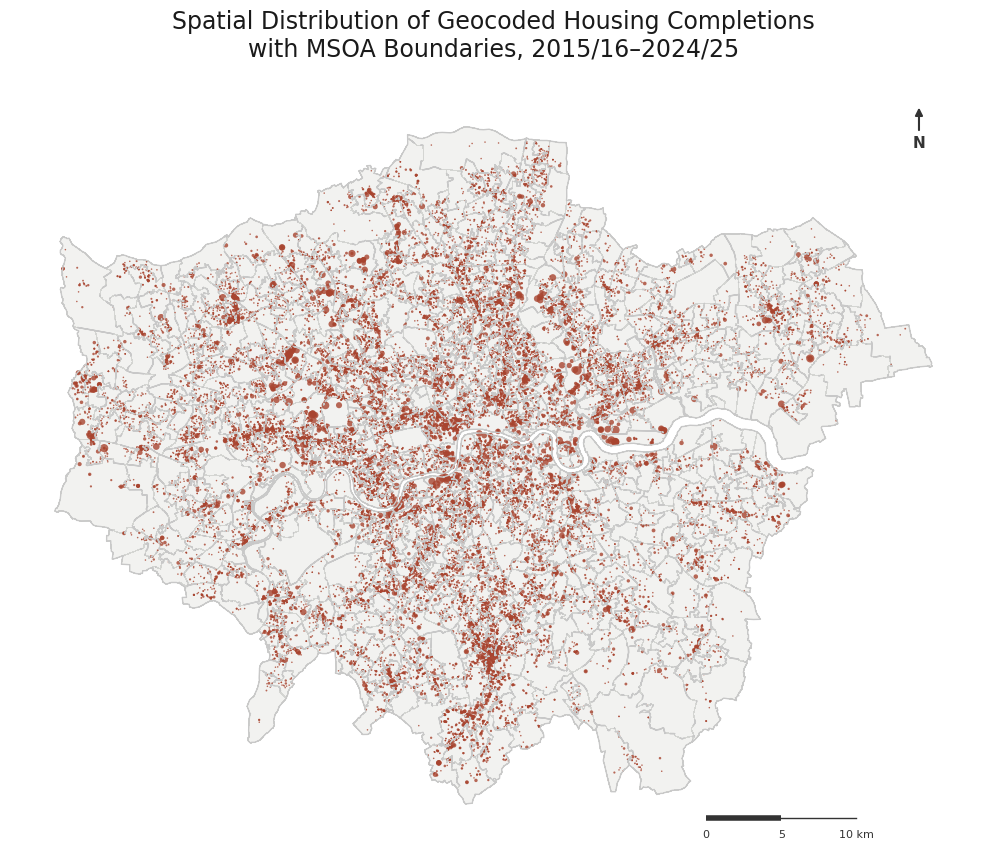

In [29]:
points_msoa = points_msoa.copy()

# Square-root scaling prevents a few very large sites
# from visually dominating the map
points_msoa["marker_size"] = (
    np.sqrt(
        points_msoa["completed_units"]
        .clip(
            lower=1,
            upper=1000,
        )
    )
    * 1.25
)


fig, ax = plt.subplots(
    figsize=(10, 10),
    facecolor="#FFFFFF",
)


# Very light MSOA background and subtle internal boundaries
msoa.plot(
    ax=ax,
    facecolor="#F2F2F0",
    edgecolor="#D4D5D2",
    linewidth=0.22,
    antialiased=False,
    zorder=1,
)


# Housing completion points
points_msoa.plot(
    ax=ax,
    color="#A8442F",
    markersize=points_msoa["marker_size"],
    alpha=0.8,
    edgecolor="none",
    linewidth=0,
    rasterized=True,
    zorder=5,
)


# Draw London outer outline more clearly
london_outline.boundary.plot(
    ax=ax,
    color="#C8C8C8",
    linewidth=1,
    zorder=10,
)


# Use the MSOA boundary to determine map extent
min_x, min_y, max_x, max_y = msoa.total_bounds
padding = 3000

ax.set_xlim(
    min_x - padding,
    max_x + padding,
)

ax.set_ylim(
    min_y - padding,
    max_y + padding,
)


ax.set_title(
    "Spatial Distribution of Geocoded Housing Completions\n"
    "with MSOA Boundaries, 2015/16–2024/25",
    pad=18,
    color="#1A1A1A",
)

ax.axis("off")

add_scale_bar(
    ax,
    length_km=10,
    location=(0.72, 0.04),
)

add_north_arrow(
    ax,
    location=(0.94, 0.92),
)


plt.tight_layout()

plt.savefig(
    FIG_DIR / "fig07_housing_completion_points_msoa.png",
    dpi=400,
    bbox_inches="tight",
    facecolor="#FFFFFF",
    pad_inches=0.18,
)

plt.show()

## 10. MSOA accessible share

In [30]:
# ---------------------------------------------------------
# Create MSOA-level accessibility dataset for Figure 8
# ---------------------------------------------------------

msoa_housing_points = points_msoa[
    points_msoa["ptal_band"].isin(
        [
            "Low",
            "Medium",
            "High",
        ]
    )
].copy()


# Medium and High correspond to PTAL 3, 4, 5, 6a and 6b
msoa_housing_points["is_medium_high_ptal"] = (
    msoa_housing_points["ptal_band"]
    .isin(
        [
            "Medium",
            "High",
        ]
    )
)


# Number of completed units located in Medium/High PTAL
msoa_housing_points["units_medium_high"] = np.where(
    msoa_housing_points["is_medium_high_ptal"],
    msoa_housing_points["completed_units"],
    0,
)


msoa_accessibility_summary = (
    msoa_housing_points
    .groupby("msoa11cd")
    .agg(
        housing_records=(
            "LPA Number",
            "count",
        ),
        completed_units=(
            "completed_units",
            "sum",
        ),
        units_medium_high=(
            "units_medium_high",
            "sum",
        ),
    )
    .reset_index()
)


msoa_accessibility_summary[
    "share_units_medium_high"
] = (
    msoa_accessibility_summary[
        "units_medium_high"
    ]
    / msoa_accessibility_summary[
        "completed_units"
    ]
)


# Percentage version produces more readable legend ranges
msoa_accessibility_summary[
    "share_units_medium_high_pct"
] = (
    msoa_accessibility_summary[
        "share_units_medium_high"
    ]
    * 100
)


msoa_accessibility_map = msoa.merge(
    msoa_accessibility_summary,
    on="msoa11cd",
    how="left",
)


print(
    "MSOAs with housing records:",
    msoa_accessibility_map[
        "completed_units"
    ].notna().sum(),
)

print(
    "MSOAs without housing records:",
    msoa_accessibility_map[
        "completed_units"
    ].isna().sum(),
)

display(
    msoa_accessibility_summary[
        [
            "msoa11cd",
            "completed_units",
            "units_medium_high",
            "share_units_medium_high",
        ]
    ].head()
)

MSOAs with housing records: 982
MSOAs without housing records: 1


,msoa11cd,completed_units,units_medium_high,share_units_medium_high
0,E02000001,540.0,540.0,1.000000
1,E02000002,4.0,0.0,0.000000
2,E02000003,77.0,67.0,0.870130
3,E02000004,52.0,0.0,0.000000
4,E02000005,11.0,6.0,0.545455


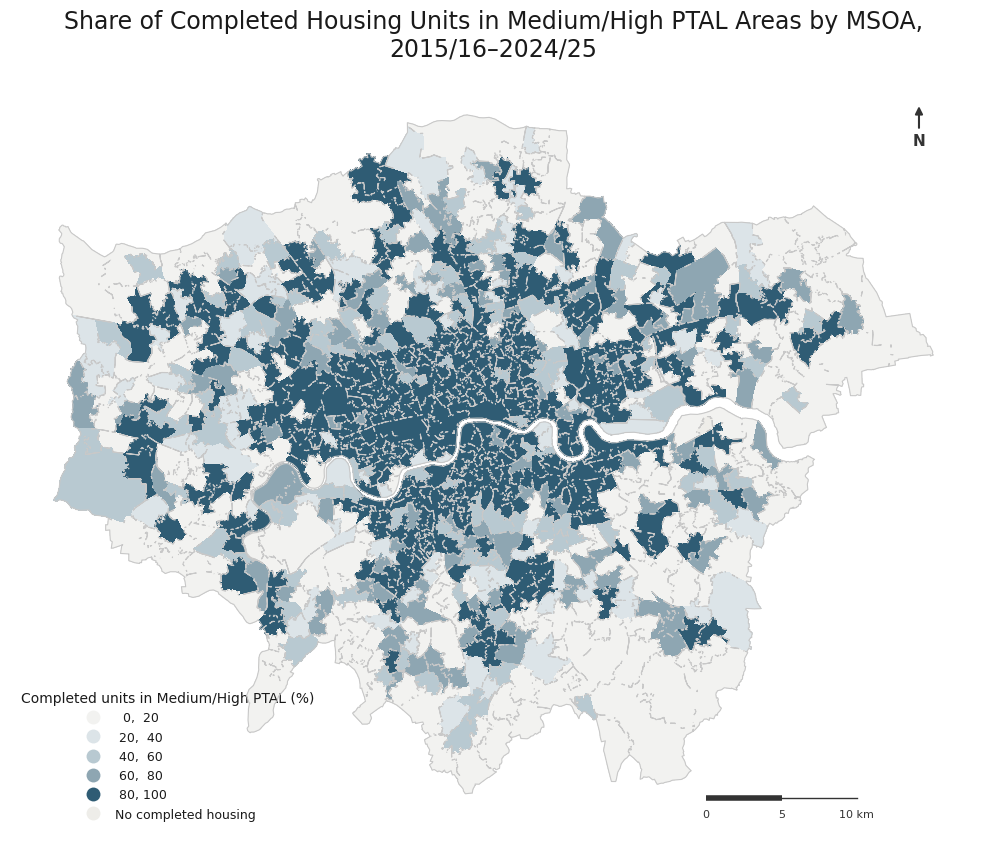

In [31]:
# ---------------------------------------------------------
# Figure 8: share in Medium/High PTAL by MSOA
# ---------------------------------------------------------

accessibility_cmap = LinearSegmentedColormap.from_list(
    "accessibility_fresh",
    [
        "#F2F2F0",
        "#DCE4E8",
        "#B8C9D1",
        "#8FA7B3",
        "#2F5C74",
    ],
)


fig, ax = plt.subplots(
    figsize=(10, 10),
    facecolor="#FFFFFF",
)


msoa_accessibility_map.plot(
    column="share_units_medium_high_pct",

    scheme="UserDefined",
    classification_kwds={
        "bins": [
            20,
            40,
            60,
            80,
            100,
        ]
    },

    cmap=accessibility_cmap,
    legend=True,

    linewidth=0,
    edgecolor="none",
    antialiased=False,

    missing_kwds={
        "color": "#EEEDE9",
        "edgecolor": "none",
        "label": "No completed housing",
    },

    ax=ax,

   legend_kwds={
    "loc": "lower left",
    "title": "Completed units in Medium/High PTAL (%)",
    "frameon": False,
    "fmt": "{:.0f}",
},

    zorder=5,
)


# Remove apparent polygon seams
remove_polygon_seams(ax)


# Draw only the London-wide external boundary
london_outline.boundary.plot(
    ax=ax,
    color="#C8C8C8",
    linewidth=0.8,
    zorder=10,
)


ax.set_title(
    "Share of Completed Housing Units in Medium/High PTAL Areas by MSOA,\n"
    "2015/16–2024/25",
    pad=18,
    color="#1A1A1A",
)

ax.axis("off")


add_scale_bar(
    ax,
    length_km=10,
    location=(0.72, 0.04),
)

add_north_arrow(
    ax,
    location=(0.94, 0.92),
)


plt.tight_layout()

plt.savefig(
    FIG_DIR / "fig08_msoa_medium_high_ptal_share.png",
    dpi=400,
    bbox_inches="tight",
    facecolor="#FFFFFF",
    pad_inches=0.18,
)

plt.show()

In [32]:
small_volume_check = pd.DataFrame({
    "threshold": [
        "Fewer than 5 completed units",
        "Fewer than 10 completed units",
        "Fewer than 20 completed units",
    ],
    "msoa_count": [
        (msoa_accessibility_summary["completed_units"] < 5).sum(),
        (msoa_accessibility_summary["completed_units"] < 10).sum(),
        (msoa_accessibility_summary["completed_units"] < 20).sum(),
    ],
})

small_volume_check

,threshold,msoa_count
0,Fewer than 5 completed units,13
1,Fewer than 10 completed units,29
2,Fewer than 20 completed units,86


## 11. Threshold sensitivity

In [33]:
def ptal_to_rank(value):
    if pd.isna(value):
        return np.nan
    
    value = str(value).strip().lower()
    
    mapping = {
        "0": 0,
        "1a": 1,
        "1b": 2,
        "2": 3,
        "3": 4,
        "4": 5,
        "5": 6,
        "6a": 7,
        "6b": 8
    }
    
    return mapping.get(value, np.nan)

analysis_gdf["ptal_rank"] = (
    analysis_gdf["PTAL_2023"]
    .apply(ptal_to_rank)
)

analysis_gdf_ptal = analysis_gdf[
    analysis_gdf["ptal_rank"].notna()
].copy()

ptal_grid["ptal_rank"] = (
    ptal_grid["PTAL_2023"]
    .apply(ptal_to_rank)
)

### 11.1 Overall threshold comparison

In [34]:
# PTAL threshold curve across all ordered PTAL levels

thresholds_curve = [
    ("PTAL ≥ 0", 0),
    ("PTAL ≥ 1a", 1),
    ("PTAL ≥ 1b", 2),
    ("PTAL ≥ 2", 3),
    ("PTAL ≥ 3", 4),
    ("PTAL ≥ 4", 5),
    ("PTAL ≥ 5", 6),
    ("PTAL ≥ 6a", 7),
    ("PTAL ≥ 6b", 8)
]

threshold_curve_rows = []

housing_units_total = analysis_gdf_ptal["completed_units"].sum()
housing_records_total = len(analysis_gdf_ptal)

ptal_grid_valid = ptal_grid[
    ptal_grid["ptal_rank"].notna()
].copy()

grid_cells_total = len(ptal_grid_valid)

for label, threshold_value in thresholds_curve:
    housing_units_accessible = analysis_gdf_ptal.loc[
        analysis_gdf_ptal["ptal_rank"] >= threshold_value,
        "completed_units"
    ].sum()
    
    housing_records_accessible = (
        analysis_gdf_ptal["ptal_rank"] >= threshold_value
    ).sum()
    
    grid_cells_accessible = (
        ptal_grid_valid["ptal_rank"] >= threshold_value
    ).sum()
    
    threshold_curve_rows.append({
        "threshold": label,
        "threshold_rank": threshold_value,
        "housing_records_accessible": housing_records_accessible,
        "housing_record_share": housing_records_accessible / housing_records_total,
        "housing_units_accessible": housing_units_accessible,
        "housing_unit_share": housing_units_accessible / housing_units_total,
        "grid_cells_accessible": grid_cells_accessible,
        "grid_cell_share": grid_cells_accessible / grid_cells_total
    })

ptal_threshold_curve = pd.DataFrame(threshold_curve_rows)

ptal_threshold_curve.to_csv(
    OUTPUT_DIR / "summary_ptal_threshold_curve.csv",
    index=False
)

ptal_threshold_curve

,threshold,threshold_rank,housing_records_accessible,housing_record_share,housing_units_accessible,housing_unit_share,grid_cells_accessible,grid_cell_share
0,PTAL ≥ 0,0,25829,1.000000,225104.0,1.000000,159451,1.000000
1,PTAL ≥ 1a,1,25597,0.991018,223694.0,0.993736,129507,0.812206
2,PTAL ≥ 1b,2,25035,0.969259,220424.0,0.979210,114192,0.716157
3,PTAL ≥ 2,3,22764,0.881335,203312.0,0.903191,84517,0.530050
4,PTAL ≥ 3,4,16687,0.646057,161645.0,0.718090,44521,0.279214
5,PTAL ≥ 4,5,11219,0.434357,120271.0,0.534291,24728,0.155082
6,PTAL ≥ 5,6,7261,0.281118,89568.0,0.397896,14781,0.092699
7,PTAL ≥ 6a,7,4637,0.179527,60649.0,0.269427,9350,0.058639
8,PTAL ≥ 6b,8,1554,0.060165,24065.0,0.106906,3220,0.020194


### 11.2 Threshold sensitivity figure

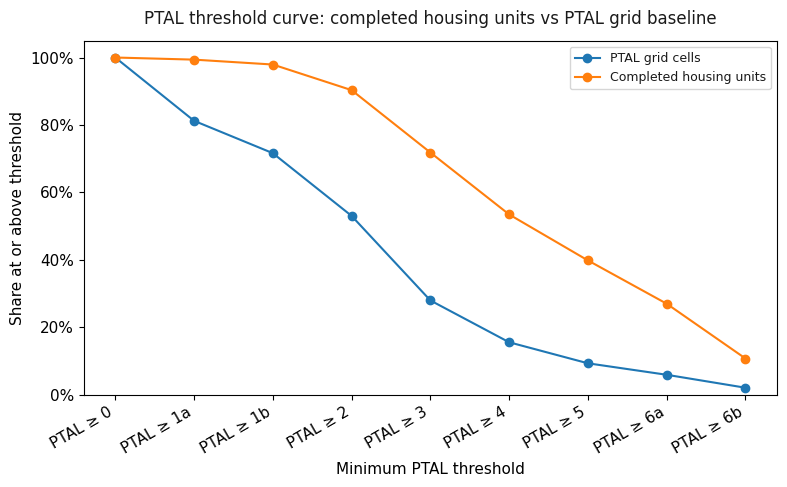

In [35]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    ptal_threshold_curve["threshold"],
    ptal_threshold_curve["grid_cell_share"],
    marker="o",
    label="PTAL grid cells"
)

ax.plot(
    ptal_threshold_curve["threshold"],
    ptal_threshold_curve["housing_unit_share"],
    marker="o",
    label="Completed housing units"
)

ax.set_title(
    "PTAL threshold curve: completed housing units vs PTAL grid baseline",
    fontsize=12,
    pad=12
)

ax.set_xlabel("Minimum PTAL threshold")
ax.set_ylabel("Share at or above threshold")
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")

plt.xticks(rotation=30, ha="right")
ax.legend()
plt.tight_layout()

plt.savefig(FIG_DIR / "fig09_ptal_threshold_curve.png", dpi=300)
plt.show()

### 11.3 Annual sensitivity

In [36]:
thresholds = {
    "PTAL ≥ 3": 4,
    "PTAL ≥ 4": 5,
    "PTAL ≥ 5": 6,
}
annual_threshold_rows = []

for year, group in analysis_gdf_ptal.groupby("completion_financial_year"):
    total_units = group["completed_units"].sum()
    
    row = {
        "completion_financial_year": year,
        "completed_units": total_units
    }
    
    for label, threshold_value in thresholds.items():
        accessible_units = group.loc[
            group["ptal_rank"] >= threshold_value,
            "completed_units"
        ].sum()
        
        row[f"share_units_{label}"] = accessible_units / total_units
    
    annual_threshold_rows.append(row)

annual_threshold_sensitivity = pd.DataFrame(annual_threshold_rows)
annual_threshold_sensitivity = annual_threshold_sensitivity.sort_values("completion_financial_year")

annual_threshold_sensitivity

,completion_financial_year,completed_units,share_units_PTAL ≥ 3,share_units_PTAL ≥ 4,share_units_PTAL ≥ 5
0,2015/16,19438.0,0.683867,0.488579,0.381624
1,2016/17,31610.0,0.747612,0.562955,0.420595
2,2017/18,26887.0,0.720311,0.528992,0.341689
3,2018/19,26279.0,0.685186,0.496975,0.360782
4,2019/20,27620.0,0.658255,0.496560,0.363831
5,2020/21,20720.0,0.669836,0.478330,0.375627
6,2021/22,21950.0,0.781367,0.588246,0.416856
7,2022/23,11068.0,0.752439,0.494940,0.360770
8,2023/24,21428.0,0.809408,0.660258,0.513907
9,2024/25,18104.0,0.688467,0.526513,0.452939


In [37]:
annual_threshold_sensitivity.to_csv(
    OUTPUT_DIR / "summary_annual_ptal_threshold_sensitivity.csv",
    index=False
)

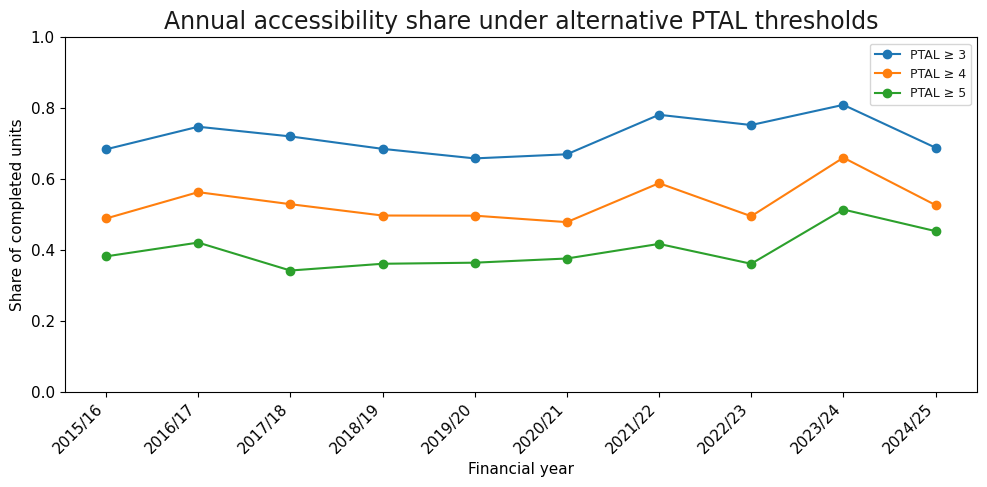

In [38]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(annual_threshold_sensitivity))

for label in thresholds.keys():
    ax.plot(
        x,
        annual_threshold_sensitivity[f"share_units_{label}"],
        marker="o",
        label=label
    )

ax.set_xticks(x)
ax.set_xticklabels(
    annual_threshold_sensitivity["completion_financial_year"],
    rotation=45,
    ha="right"
)

ax.set_ylim(0, 1)
ax.set_ylabel("Share of completed units")
ax.set_xlabel("Financial year")
ax.set_title("Annual accessibility share under alternative PTAL thresholds")
ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "fig10_annual_ptal_threshold_sensitivity.png", dpi=300)
plt.show()

### 11.4 Borough sensitivity

In [39]:
borough_threshold_rows = []

for borough, group in analysis_gdf_ptal.dropna(subset=["borough_spatial"]).groupby("borough_spatial"):
    total_units = group["completed_units"].sum()
    
    row = {
        "borough_spatial": borough,
        "completed_units": total_units
    }
    
    for label, threshold_value in thresholds.items():
        accessible_units = group.loc[
            group["ptal_rank"] >= threshold_value,
            "completed_units"
        ].sum()
        
        row[f"share_units_{label}"] = accessible_units / total_units
    
    borough_threshold_rows.append(row)

borough_threshold_sensitivity = pd.DataFrame(borough_threshold_rows)

borough_threshold_sensitivity = borough_threshold_sensitivity.sort_values(
    "share_units_PTAL ≥ 3",
    ascending=False
)

borough_threshold_sensitivity.head(10)

,borough_spatial,completed_units,share_units_PTAL ≥ 3,share_units_PTAL ≥ 4,share_units_PTAL ≥ 5
6,City of London,540.0,1.000000,1.000000,1.000000
32,Westminster,7432.0,0.995694,0.938375,0.860334
18,Islington,1880.0,0.953191,0.889894,0.846809
21,Lambeth,7057.0,0.917387,0.800623,0.702140
5,Camden,5563.0,0.900413,0.820241,0.739170
27,Southwark,8759.0,0.883777,0.711497,0.608631
10,Greenwich,3544.0,0.867664,0.508465,0.339447
11,Hackney,7491.0,0.846215,0.684688,0.482312
3,Brent,12664.0,0.846178,0.619394,0.454991
31,Wandsworth,12758.0,0.839003,0.653080,0.489262


In [41]:
borough_threshold_sensitivity.to_csv(
    OUTPUT_DIR / "summary_borough_ptal_threshold_sensitivity.csv",
    index=False
)